In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gensim import corpora
import gensim
from gensim.models import CoherenceModel
from tqdm import tqdm
import gc

# Load data
grid_df = pd.read_csv("./data/cell_POIcat.csv.gz")
poi_map = pd.read_csv("./data/POI_datacategories.csv", header=None)



In [2]:
zones = ["Arts and Entertainment", "Business and Professional Services",
    "Community and Government", "Dining and Drinking", "Event",
    "Health and Medicine", "Landmarks and Outdoors", "Nightlife Spot",
    "Retail", "Sports and Recreation", "Travel and Transportation"]

zone_mapping = {
       "Food": "Dining and Drinking",
    "Shopping": "Retail",
    "Entertainment": "Arts and Entertainment",
    "Japanese restaurant": "Dining and Drinking",
    "Western restaurant": "Dining and Drinking",
    "Eat all you can restaurant": "Dining and Drinking",
    "Chinese restaurant": "Dining and Drinking",
    "Indian restaurant": "Dining and Drinking",
    "Ramen restaurant": "Dining and Drinking",
    "Curry restaurant": "Dining and Drinking",
    "BBQ restaurant": "Dining and Drinking",
    "Hot pot restaurant": "Dining and Drinking",
    "Bar": "Dining and Drinking",
    "Diner": "Dining and Drinking",
    "Creative cuisine": "Dining and Drinking",
    "Organic cuisine": "Dining and Drinking",
    "Pizza": "Dining and Drinking",
    "Café": "Dining and Drinking",
    "Tea Salon": "Dining and Drinking",
    "Bakery": "Dining and Drinking",
    "Sweets ": "Dining and Drinking",
    "Wine Bar": "Dining and Drinking",
    "Pub": "Dining and Drinking",
    "Disco": "Arts and Entertainment",
    "Beer Garden": "Dining and Drinking",
    "Fast Food": "Dining and Drinking",
    "Karaoke": "Arts and Entertainment", 
    "Cruising": "Travel and Transportation", 
    "Theme Park Restaurant": "Dining and Drinking",
    "Amusement Restaurant": "Dining and Drinking",
    "Other Restaurants": "Dining and Drinking",
    "Glasses": "Retail",
    "Drug Store": "Retail",
    "Electronics Store": "Retail",
    "DIY Store": "Retail",
    "Convenience Store": "Retail",
    "Recycle Shop": "Retail",
    "Interior Shop": "Retail",
    "Sports Store": "Retail",
    "Clothes Store": "Retail",
    "Grocery Store": "Retail",
    "Online Grocery Store": "Retail",
    "Sports Recreation": "Sports and Recreation",
    "Game Arcade": "Arts and Entertainment",
    "Swimming Pool": "Sports and Recreation",
    "Hotel": "Travel and Transportation",
    "Park": "Landmarks and Outdoors",
    "Transit Station": "Travel and Transportation",
    "Parking Area": "Travel and Transportation",
    "Casino": "Arts and Entertainment",
    "Hospital": "Health and Medicine",
    "Pharmacy": "Health and Medicine",
    "Chiropractic": "Health and Medicine",
    "Elderly Care Home": "Community and Government", 
    "Fishing": "Sports and Recreation",
    "School": "Community and Government",
    "Cram School": "Community and Government",
    "Kindergarten": "Community and Government",
    "Real Estate": "Business and Professional Services",
    "Home Appliances": "Retail",
    "Post Office": "Community and Government",
    "Laundry ": "Business and Professional Services",
    "Driving School": "Community and Government",
    "Wedding Ceremony": "Business and Professional Services", 
    "Cemetary": "Community and Government",
    "Bank": "Business and Professional Services",
    "Vet": "Health and Medicine",
    "Hot Spring": "Landmarks and Outdoors",
    "Hair Salon": "Business and Professional Services",
    "Lawyer Office": "Business and Professional Services",
    "Recruitment Office": "Business and Professional Services",
    "City Hall": "Community and Government",
    "Community Center": "Community and Government",
    "Church": "Community and Government",
    "Retail Store": "Retail",
    "Accountant Office": "Business and Professional Services",
    "IT Office": "Business and Professional Services",
    "Publisher Office": "Business and Professional Services",
    "Building Material": "Retail",
    "Gardening": "Retail",
    "Heavy Industry": "Business and Professional Services",
    "NPO": "Community and Government",
    "Utility Copany": "Business and Professional Services",
    "Port": "Travel and Transportation",
    "Research Facility": "Business and Professional Services"
}

grid_df['POI_name'] = (grid_df['POIcategory'] - 1).map(poi_map.iloc[:,0])
grid_df["zone"] = grid_df["POI_name"].map(zone_mapping).fillna("Other")

grid_docs = []
cell_keys = []
for (x, y), g in grid_df.groupby(['x', 'y']):
    tokens = [row['zone'] for _, row in g.iterrows() for _ in range(int(row['POI_count']))]
    if len(tokens) > 0:  # Only non-empty documents
        grid_docs.append(tokens)
        cell_keys.append((x, y))

print(f"Total documents: {len(grid_docs)}")
print(f"Sample document: {grid_docs[0][:10]}")

dictionary = corpora.Dictionary(grid_docs)
for z in zones:
    if z not in dictionary.token2id:
        dictionary.add_documents([[z]])

corpus = [dictionary.doc2bow(doc) for doc in grid_docs]

print(f"Vocabulary size: {len(dictionary)}")
print(f"Corpus size: {len(corpus)}")


Total documents: 20146
Sample document: ['Travel and Transportation', 'Travel and Transportation', 'Travel and Transportation', 'Travel and Transportation', 'Community and Government', 'Business and Professional Services', 'Business and Professional Services', 'Business and Professional Services', 'Community and Government', 'Community and Government']
Vocabulary size: 11
Corpus size: 20146


In [3]:
# Coherence and Perplexity

def compute_metrics(corpus, dictionary, limit=12):

    perplexity_values = []
    model_list = []
    
    for num_topics in tqdm(range(2, limit + 1), desc="Computing metrics"):
        model = gensim.models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10, 
            iterations=50,
            alpha='auto',
            eta='auto',
            per_word_topics=True
        )
        model_list.append(model)
        
        # Perplexity
        perplexity = model.log_perplexity(corpus)
        perplexity_values.append(perplexity)

        print(f"Topics: {num_topics}, Perplexity: {perplexity:.4f}")
    return range(2, limit + 1), perplexity_values, model_list

topic_range, perplexity_vals, models = compute_metrics(
    corpus, dictionary = dictionary
)
# Coherence_UMass
coherence_values = []
for num_topics in tqdm(range(2, 13), desc="U_MASS coherence"):
    model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        iterations=50
    )
    cm = CoherenceModel(
        model=model,
        corpus=corpus,
        dictionary=dictionary,
        coherence='u_mass'
    )
    
    coherence = cm.get_coherence()
    coherence_values.append(coherence)
        
    print(f"Topics: {num_topics}, U_MASS: {coherence:.4f}")
    
    



Computing metrics:   9%|▉         | 1/11 [00:20<03:27, 20.75s/it]

Topics: 2, Perplexity: -1.7783


Computing metrics:  18%|█▊        | 2/11 [00:43<03:18, 22.02s/it]

Topics: 3, Perplexity: -1.7765


Computing metrics:  27%|██▋       | 3/11 [01:00<02:35, 19.47s/it]

...

Topics: 10, U_MASS: -9.3243


U_MASS coherence:  91%|█████████ | 10/11 [11:18<01:11, 71.37s/it]

Topics: 11, U_MASS: -9.3566


U_MASS coherence: 100%|██████████| 11/11 [12:33<00:00, 68.54s/it]

Topics: 12, U_MASS: -9.3428


In [12]:
from scipy.spatial.distance import jensenshannon

def topic_diversity_score(model, num_topics):
    """Calculate average pairwise distance between topics"""
    topic_distributions = []
    vocab_size = len(model.id2word)
    
    for topic_id in range(num_topics):
        topic_dist = np.zeros(vocab_size)
        for word_id, prob in model.get_topic_terms(topic_id, topn=vocab_size):
            topic_dist[word_id] = prob
        topic_distributions.append(topic_dist)
    
    # Pairwise JS divergence
    distances = []
    for i in range(num_topics):
        for j in range(i + 1, num_topics):
            dist = jensenshannon(topic_distributions[i], topic_distributions[j])
            distances.append(dist)
    
    return np.mean(distances), distances

# Diversity score for different topic counts
diversity_scores = []
for num_topics in tqdm (range(2, 11), desc="Topic diversity"):
    model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=20
    )
    avg_div, _ = topic_diversity_score(model, num_topics)
    diversity_scores.append(avg_div)

Topic diversity: 100%|██████████| 9/9 [16:47<00:00, 111.96s/it]


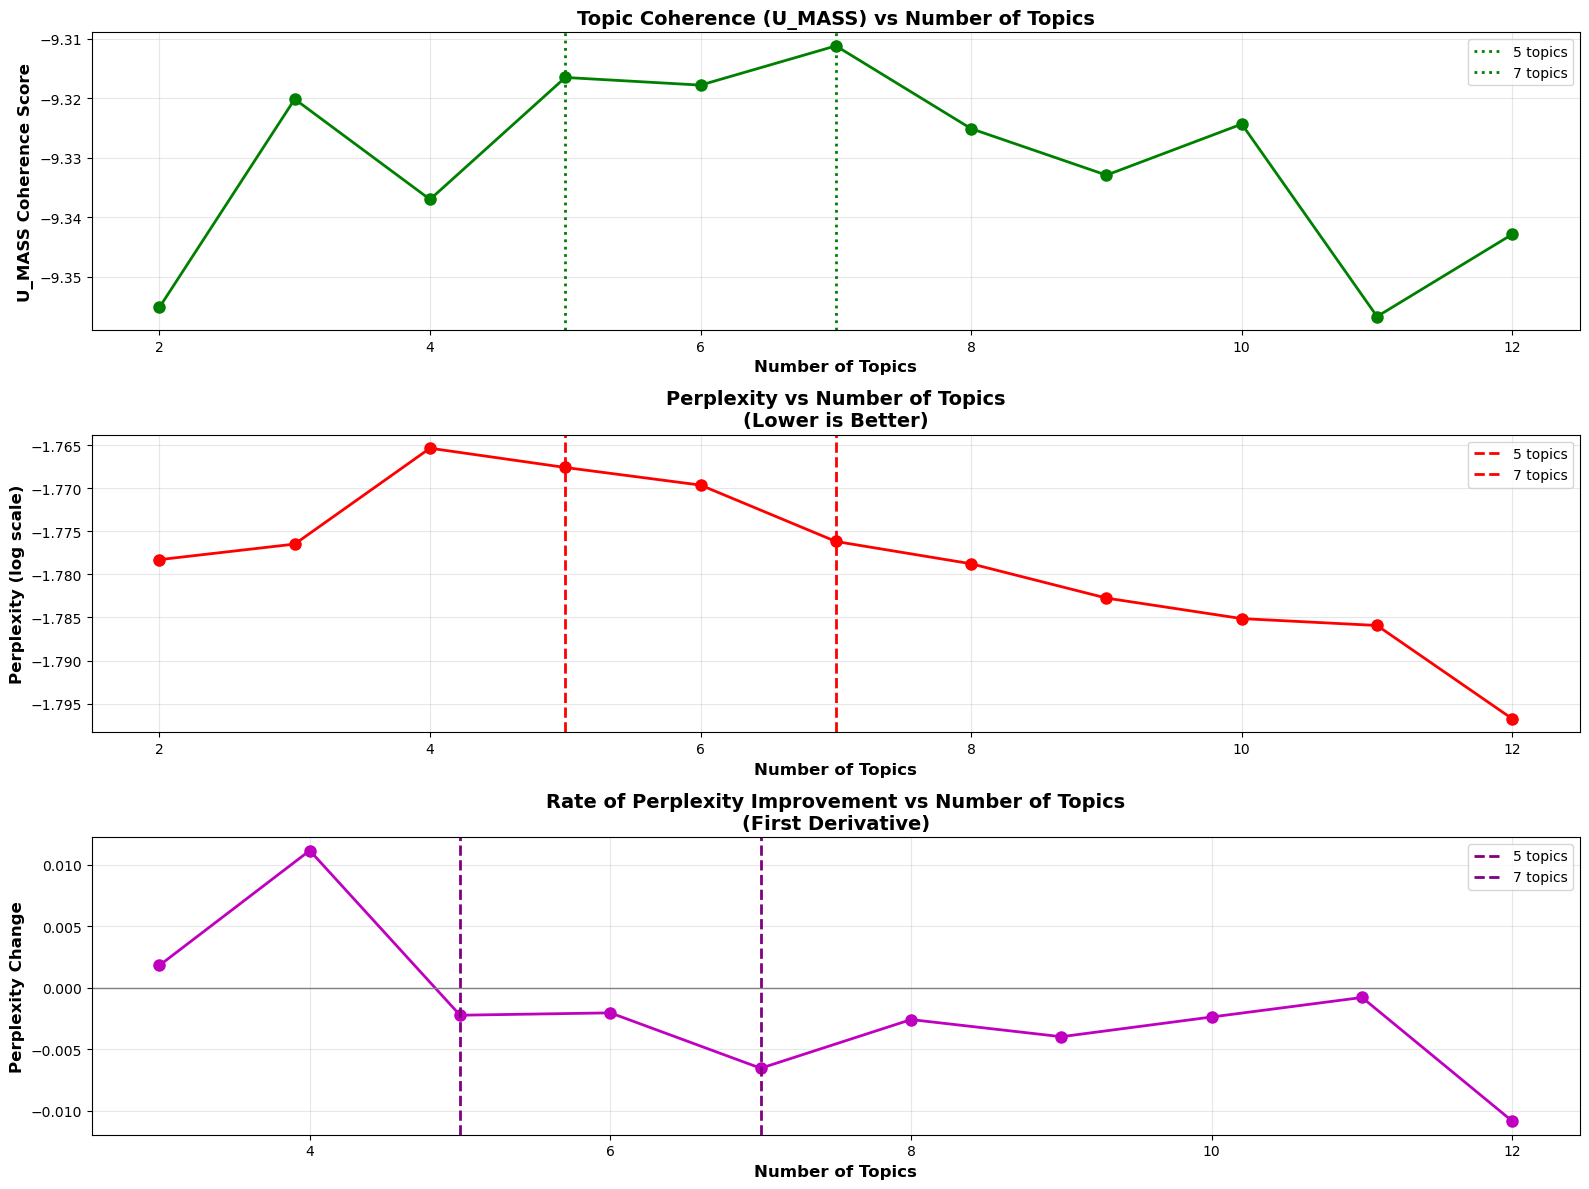

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))


#  U_MASS Coherence (closer to 0 is better)
axes[0].plot(range(2, 13), coherence_values, 'go-', linewidth=2, markersize=8)
max_umass_idx = np.argmax(coherence_values)  # Closer to 0 is better (less negative)
axes[0].axvline(x=5, color='green', linestyle=':', linewidth=2,
                 label=f'5 topics')
axes[0].axvline(x=max_umass_idx + 2, color='green', linestyle=':', 
                   linewidth=2, label=f'{max_umass_idx + 2} topics') 
axes[0].set_xlabel('Number of Topics', fontsize=12, fontweight='bold')
axes[0].set_ylabel('U_MASS Coherence Score', fontsize=12, fontweight='bold')
axes[0].set_title('Topic Coherence (U_MASS) vs Number of Topics', 
                     fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Perplexity
axes[1].plot(topic_range, perplexity_vals, 'ro-', linewidth=2, markersize=8)
axes[1].axvline(x=5, color='red', linestyle='--', linewidth=2,
                 label=f'5 topics')
axes[1].axvline(x=max_umass_idx + 2, color='red', linestyle='--', linewidth=2,
                 label=f'{max_umass_idx + 2} topics') #Offset by 2 because topic_range starts at 2 
axes[1].set_xlabel('Number of Topics', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Perplexity (log scale)', fontsize=12, fontweight='bold')
axes[1].set_title('Perplexity vs Number of Topics\n(Lower is Better)', 
                     fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend()

# Rate of change in perplexity
perplexity_diffs = np.diff(perplexity_vals)
axes[2].plot(list(topic_range)[1:], perplexity_diffs, 'mo-', linewidth=2, markersize=8)
axes[2].axvline(x=5, color='purple', linestyle='--', linewidth=2,
                 label=f'5 topics')
axes[2].axvline(x=max_umass_idx + 2, color='purple', linestyle='--', linewidth=2,
                 label=f'{max_umass_idx + 2} topics') 
axes[2].axhline(y=0, color='gray', linestyle='-', linewidth=1)
axes[2].set_xlabel('Number of Topics', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Perplexity Change', fontsize=12, fontweight='bold')
axes[2].set_title('Rate of Perplexity Improvement vs Number of Topics\n(First Derivative)', 
                     fontsize=14, fontweight='bold')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig('figures/topic_selection.png', dpi=300, bbox_inches='tight')
plt.show()

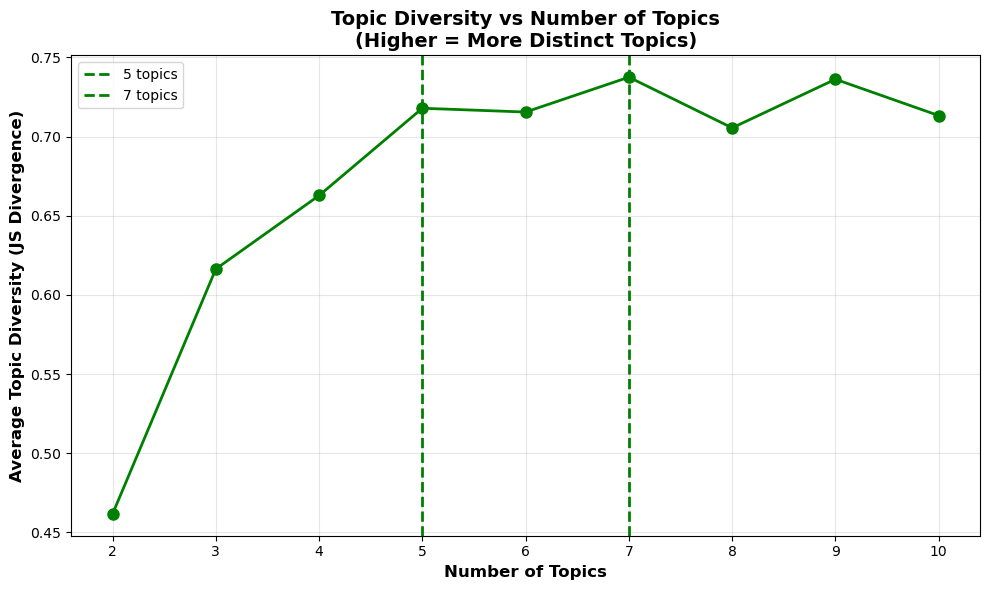

In [13]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), diversity_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Topics', fontsize=12, fontweight='bold')
plt.axvline(x=5, color='green', linestyle='--', linewidth=2,
                 label=f'5 topics')
plt.axvline(x=max_umass_idx + 2, color='green', linestyle='--', linewidth=2,
                 label=f'{max_umass_idx + 2} topics') 
plt.ylabel('Average Topic Diversity (JS Divergence)', fontsize=12, fontweight='bold')
plt.title('Topic Diversity vs Number of Topics\n(Higher = More Distinct Topics)', 
          fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('figures/topic_diversity_analysis.png', dpi=300, bbox_inches='tight')
plt.show()